# SSIM (Structural Similarity Index Measure)

Structural Similarity Index Measure (SSIM) is a metric used to measure the similarity between two images by comparing their structure, luminance, and contrast.
Instead of looking at raw pixel differences, SSIM evaluates how similar the perceptual structure of two images is, which makes it closer to human visual perception than simple error metrics like MSE.

In [32]:
# Switch path to root of project
import os
os.environ["CUDA_VISIBLE_DEVICES"]="0"
current_folder = globals()['_dh'][0]
os.chdir(os.path.dirname(os.path.abspath(current_folder)))
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
import cv2
import numpy as np
import torch
from PIL import Image
from pathlib import Path
from tqdm import tqdm
from eval.utils import RGBFIDDataset, compute_fid, compute_ssim, preprocess_single_image
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF

from torch.utils.data import Dataset, DataLoader
device = "cuda" if torch.cuda.is_available() else "cpu"

## SSIM with same image:
Must be 1

In [34]:
crop_settings_01_pth = "/work/com-304/datasets/clevr_com_304/train/crop_settings/00001.npy"
img1_pth = "/scratch/tmaillar/rgb/train/point_30_view_0_domain_rgb.png"
img2_pth = img1_pth

img1 = preprocess_single_image(img1_pth, crop_settings=np.load(crop_settings_01_pth), aug_idx=1, image_size=256)
img2 = preprocess_single_image(img2_pth, crop_settings=np.load(crop_settings_01_pth), aug_idx=1, image_size=256)
                        
score = compute_ssim(
    img1,
    img2,
    device=device)

print(f"SSIM score = {score}")

SSIM score = 1.0


## SSIM with same image + noise:

### noise_std = 0.05:

In [41]:
def to_img(x):
    return x.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()

SSIM score = 0.34188514947891235


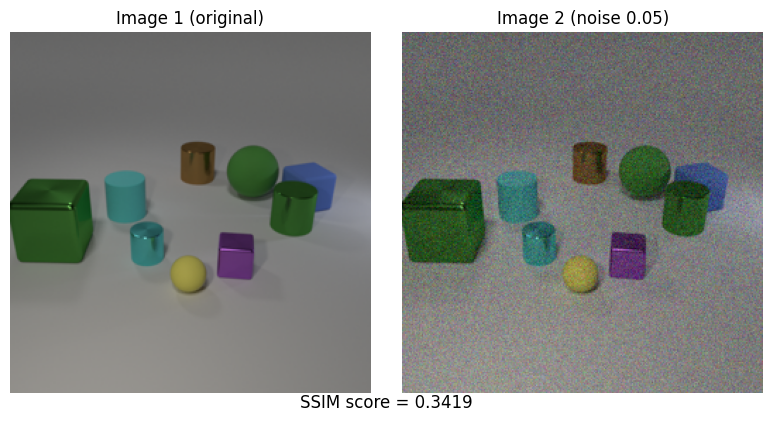

In [49]:
img1 = preprocess_single_image(img1_pth, crop_settings=np.load(crop_settings_01_pth), aug_idx=1, image_size=256)
img2 = preprocess_single_image(img2_pth, crop_settings=np.load(crop_settings_01_pth), aug_idx=1, image_size=256)

noise_std = 0.05

img2 = (img2 + torch.randn_like(img2) * noise_std).clamp(0, 1)

score = compute_ssim(
    img1,
    img2,
    device=device)

print(f"SSIM score = {score}")

img1_vis = to_img(img1)
img2_vis = to_img(img2)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].imshow(img1_vis)
ax[0].set_title("Image 1 (original)")
ax[0].axis("off")

ax[1].imshow(img2_vis)
ax[1].set_title(f"Image 2 (noise {noise_std})")
ax[1].axis("off")

fig.text(
    0.5,
    0,
    f"SSIM score = {score:.4f}",
    ha="center",
    fontsize=12
)

plt.tight_layout()
plt.show()

### noise_std = 0.1:

SSIM score = 0.1370990127325058


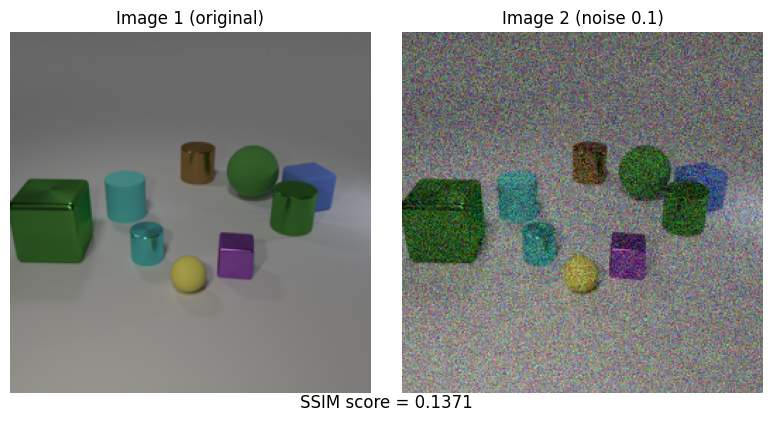

In [50]:
img2 = preprocess_single_image(img2_pth, crop_settings=np.load(crop_settings_01_pth), aug_idx=1, image_size=256)

noise_std = 0.1

img2 = (img2 + torch.randn_like(img2) * noise_std).clamp(0, 1)

score = compute_ssim(
    img1,
    img2,
    device=device)

print(f"SSIM score = {score}")

img1_vis = to_img(img1)
img2_vis = to_img(img2)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].imshow(img1_vis)
ax[0].set_title("Image 1 (original)")
ax[0].axis("off")

ax[1].imshow(img2_vis)
ax[1].set_title(f"Image 2 (noise {noise_std})")
ax[1].axis("off")

fig.text(
    0.5,
    0,
    f"SSIM score = {score:.4f}",
    ha="center",
    fontsize=12
)

plt.tight_layout()
plt.show()